In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# Read Data

df = pd.read_csv("UpdatedResumeDataSet.csv")

In [37]:
# Some Info About Data

print("Show First 5 Samples of data:")
print(df.head())

print(f"Shape of data is: {df.shape}")

print("Different Categories in data:")
print(df["Category"].value_counts())

Show First 5 Samples of data:
       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...
Shape of data is: (962, 2)
Different Categories in data:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness    

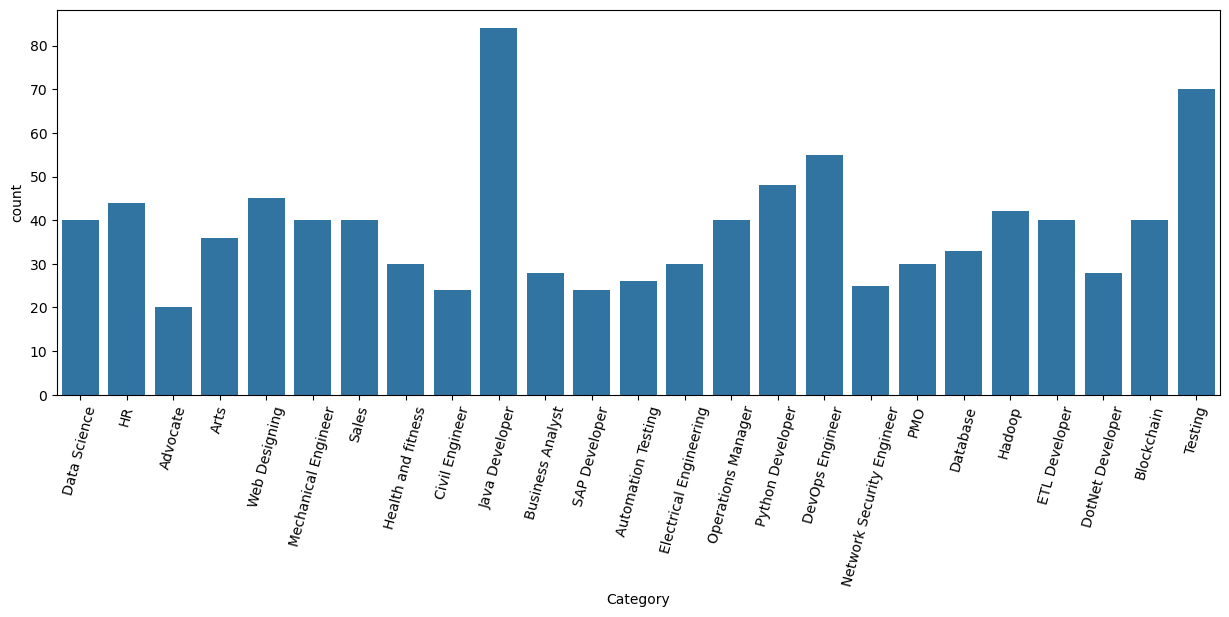

In [38]:
# Show different Categories

plt.figure(figsize=(15, 5))
sns.countplot(x = "Category", data = df)
plt.xticks(rotation = 75)
plt.show()

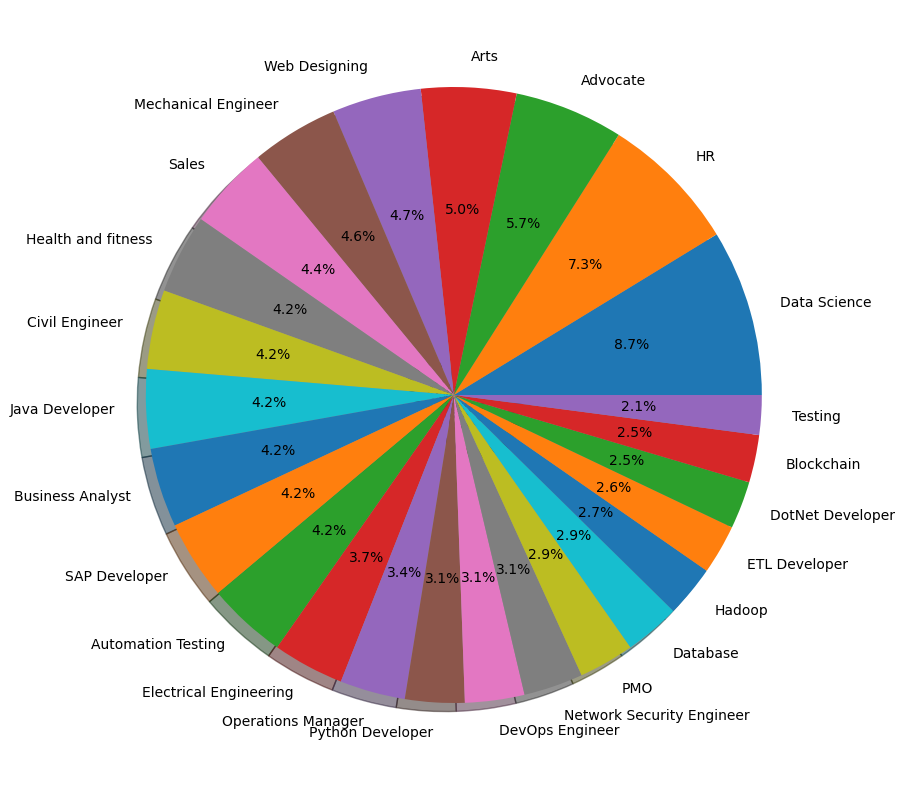

In [39]:
# Show different Categories

counts = df["Category"].value_counts()
labels = df["Category"].unique()

plt.figure(figsize=(15,10))
plt.pie(counts, labels=labels, autopct="%1.1f%%", shadow=True)
plt.show()

In [40]:
import re

def cleanResume(txt):
  # To remove Links
  cleanText = re.sub("http\S+\s", " ", txt)
  # To remove RT, cc
  cleanText = re.sub("RT|cc", " ", cleanText)
  # To remove Hashtags
  cleanText = re.sub("#\S+\s", " ", cleanText)
  # To remove Mentions
  cleanText = re.sub("#@\S+", " ", cleanText)
  # To remove Punctutations
  cleanText = re.sub("[%s]" % re.escape(""""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), " ", cleanText)
  # To remove Non-ASCII
  cleanText = re.sub(r'[^\x00-\x7f]', " ", cleanText)
  # To remove Spaces
  cleanText = re.sub(r'\s+', " ", cleanText)

  return cleanText

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\]'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\]'
C:\Users\Moham\AppData\Local\Temp\ipykernel_18816\1747155924.py:5: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub("http\S+\s", " ", txt)
C:\Users\Moham\AppData\Local\Temp\ipykernel_18816\1747155924.py:9: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub("#\S+\s", " ", cleanText)
C:\Users\Moham\AppData\Local\Temp\ipykernel_18816\1747155924.py:11: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub("#@\S+", " ", cleanText)
C:\Users\Moham\AppData\Local\Temp\ipykernel_18816\1747155924.py:13: SyntaxWarning: invalid escape sequence '\]'
  cleanText =

In [41]:
# Clean Resume

df["Resume"] = df["Resume"].apply(lambda x: cleanResume(x))

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df["Category"])
df["Category"] = le.transform(df["Category"])

print(df["Category"])

0       6
1       6
2       6
3       6
4       6
       ..
957    23
958    23
959    23
960    23
961    23
Name: Category, Length: 962, dtype: int64


In [ ]:
# Apply Tfidf

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf.fit(df["Resume"])
requiredText = tfidf.transform(df["Resume"])

In [47]:
# Split Data

from sklearn.model_selection import train_test_split

X = requiredText
y = df["Category"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X Train Shape {x_train.shape}")
print(f"X Test Shape {x_test.shape}")

X Train Shape (769, 7567)
X Test Shape (193, 7567)


In [49]:
# Train Model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(KNeighborsClassifier())
clf.fit(x_train, y_train)

,estimator,KNeighborsClassifier()
,n_jobs,None
,verbose,0
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [51]:
# Evaluate Model

from sklearn.metrics import accuracy_score

y_pred = clf.predict(x_test)
acc = accuracy_score(y_test, y_pred)

print(f"Model Accuracy is: {acc}")

Model Accuracy is: 0.9844559585492227


In [55]:
# Save Model

import pickle

pickle.dump(le, open("le.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(clf, open("clf.pkl", "wb"))